# 생성형 AI 예제 및 실습

이 노트북은 **`이미지 생성`, `비디오 생성`, `음악 생성`, `3D 그래픽 생성` 기초 예제 실습**을 수행하는 노트북입니다.

✅ 내용  
1. Stable Diffusion을 활용한 Text To Image 생성 예제
2. Stable Diffusion을 활용한 Image To Image 생성 예제
3. Stable Video Diffusion을 활용한 Image To Video 생성 예제
4. MusicGen을 활용한 Text To Music 생성 예제
5. Point-E를 활용한 Text To 3D 생성 예제
6. Point-E를 활용한 Image To 3D 생성 예제
7. Roblox Cube 3D를 활용한 Text To 3D 생성 예제

In [1]:
%conda env create -f generative_ai.yaml -n generative_ai


Note: you may need to restart the kernel to use updated packages.



CondaValueError: prefix already exists: C:\Users\ceo\miniforge3\envs\generative_ai



### Stable Diffusion을 활용한 Text To Image 생성 예제
Stable Diffusion v1.5 모델을 로드하여 텍스트 프롬프트를 통해 고품질 이미지를 생성합니다. 
프롬프트로 이미지를 생성하고 Jupyter 환경에서 인라인으로 결과를 표시합니다.

* diffusers 라이브러리에서 StableDiffusionPipeline을 사용하여 runwayml/stable-diffusion-v1-5 모델 로드 및 CUDA GPU로 이동
* "A watercolor painting of the Seoul city skyline at sunset" 텍스트 프롬프트를 입력하여 이미지 생성 수행
* 생성된 이미지 객체를 추출하고 IPython.display 모듈을 통해 Jupyter 노트북에서 인라인으로 이미지 출력

12.8
True


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

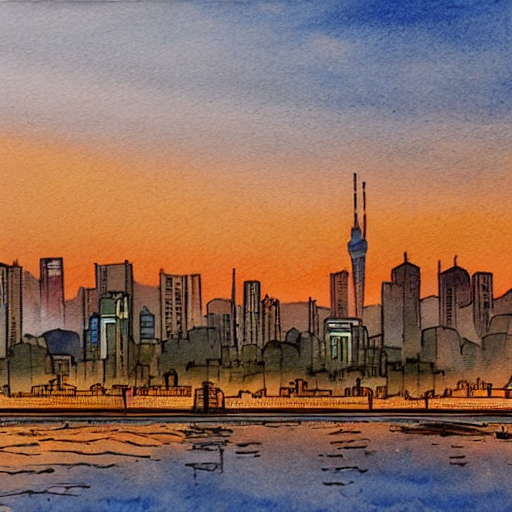

In [2]:
from diffusers import StableDiffusionPipeline
from IPython.display import display

import torch
print(torch.version.cuda)        # CUDA 버전 출력 (ex. 12.8)
print(torch.cuda.is_available()) # True여야 GPU 사용 가능


# 모델 로드
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,  # float32 대신 float16 사용
    safety_checker=None,        # safety 검사 비활성화로 메모리 절약
    requires_safety_checker=False
).to("cuda")

pipe.enable_attention_slicing()  # 어텐션 슬라이싱 활성화
pipe.enable_vae_slicing()        # VAE 슬라이싱 활성화
pipe.enable_model_cpu_offload()  # CPU 오프로드 활성화

# 프롬프트로 이미지 생성 및 인라인 출력
generated = pipe("A watercolor painting of the Seoul city skyline at sunset")
img = generated.images[0]
display(img)

### Stable Diffusion을 활용한 Image To Image 생성 예제
Stable Diffusion의 Image-to-Image 파이프라인을 로드하여 기존 이미지를 텍스트 프롬프트에 따라 새로운 스타일로 변환합니다. 
산 스케치 이미지를 판타지 풍경으로 변환하고 strength 파라미터로 변환 강도를 조절합니다.

* StableDiffusionImg2ImgPipeline을 사용하여 runwayml/stable-diffusion-v1-5 모델을 float16 타입으로 로드하고 CUDA로 이동
* GitHub에서 산 스케치 이미지를 다운로드하여 PIL Image로 변환하고 768x512 크기로 리사이즈 전처리
* "A fantasy landscape, trending on artstation" 프롬프트와 strength=0.75 설정으로 이미지 변환 수행
* 생성된 결과 이미지를 "fantasy_landscape_from_sketch.png" 파일로 저장하고 출력

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

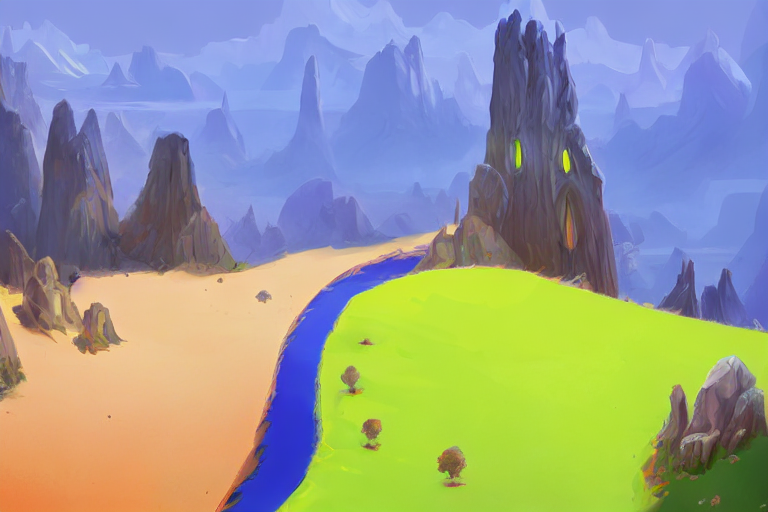

In [3]:
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import requests
from io import BytesIO
import torch

# 1) Img2Img 파이프라인 로드
pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,  # float32 대신 float16 사용
    safety_checker=None,        # safety 검사 비활성화로 메모리 절약
    requires_safety_checker=False
).to("cuda")

pipe.enable_attention_slicing()  # 어텐션 슬라이싱 활성화
pipe.enable_vae_slicing()        # VAE 슬라이싱 활성화
pipe.enable_model_cpu_offload()  # CPU 오프로드 활성화

# 2) 초기 이미지 불러오기
#url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
#init_image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
#init_image = init_image.resize((768, 512))
image_path = "./image/sketch-mountains-input.jpg"
init_image = Image.open(image_path).convert("RGB")
init_image = init_image.resize((768, 512))


prompt = "A fantasy landscape, trending on artstation"
strength = 0.75  # 0.0~1.0

# 3) 변환 실행
result = pipe_img2img(
    prompt=prompt, image=init_image, strength=strength, guidance_scale=7.5
)
out_image = result.images[0]
out_image.save("./image/fantasy_landscape_from_sketch.png")
out_image

### Stable Video Diffusion을 활용한 Image To Video 생성 예제
Stability AI의 Stable Video Diffusion 모델을 로드하여 정적 이미지에서 동적 비디오를 생성합니다. 

입력 이미지를 기반으로 자연스러운 움직임이 있는 비디오 프레임을 생성하고 MP4 파일로 저장하여 재생합니다.

* StableVideoDiffusionPipeline을 사용하여 stabilityai/stable-video-diffusion-img2vid-xt 모델을 float16 타입으로 로드하고 CPU 오프로드 활성화
* "dog_in_park.png" 이미지를 로드하여 1024x576 크기로 리사이즈하고 시드값 42로 재현가능한 결과 설정
* 이미지를 입력으로 비디오 프레임을 생성하고 7fps로 "generated.mp4" 파일로 내보내기 수행
* IPython Video 모듈을 통해 Jupyter 노트북에서 생성된 비디오를 800x450 크기로 인라인 재생

In [1]:
import torch

from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import load_image, export_to_video
from IPython.display import Video, display

# 모델 로드
pipe = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid-xt", torch_dtype=torch.float16, variant="fp16"
)
pipe.enable_attention_slicing()  # 어텐션 슬라이싱 활성화
pipe.enable_model_cpu_offload()  # CPU 오프로드 활성화

# 입력 이미지 로드 (사용자가 제공한 이미지를 사용해야 함)
image = load_image("./image/dog_in_park.png") # 사전에 준비된 이미지 파일 필요
image = image.resize((1024, 576))

# 비디오 생성
generator = torch.manual_seed(42)
frames = pipe(image, decode_chunk_size=8, generator=generator).frames[0]

video_path="./image/generated.mp4"
export_to_video(frames, video_path, fps=7)
display(Video(video_path, width=800, height=450))

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

### MusicGen을 활용한 Text To Music 생성 예제
Facebook의 MusicGen Medium 모델을 로드하여 텍스트 프롬프트를 통해 고품질 음악을 생성합니다. 

프롬프트로 음악을 생성하고 WAV 파일로 저장하여 재생합니다.

* transformers 라이브러리의 text-to-audio 파이프라인을 사용하여 facebook/musicgen-medium 모델 로드
* "ambient electronic music with a calm piano melody and soft synth pads" 텍스트 프롬프트 설정
* do_sample=True, max_new_tokens=256 파라미터로 음악 생성 수행하고 NumPy 배열과 샘플링 레이트 추출
* scipy.io.wavfile을 사용하여 "generated_music.wav" 파일로 저장하고 IPython Audio로 Jupyter에서 인라인 재생

In [1]:
from transformers import pipeline
import scipy.io.wavfile as wavfile
from IPython.display import Audio, display

# 1) MusicGen 파이프라인 로드 (medium 모델)
musicgen = pipeline("text-to-audio", model="facebook/musicgen-small")

prompt = "ambient electronic music with a calm piano melody and soft synth pads"

# 2) 음악 생성
output = musicgen(prompt, forward_params={"do_sample": True, "max_new_tokens": 256})
audio = output["audio"]             # NumPy 배열
sr = output["sampling_rate"]        # 예: 32000
filename = "./image/generated_music.wav"
# 3) WAV로 저장
wavfile.write(filename, rate=sr, data=audio)
print(f"음악 저장: generated_music.wav (길이 {audio.shape[-1]/sr:.1f}초)")
display(Audio(audio[0], rate=sr))


Config of the text_encoder: <class 'transformers.models.t5.modeling_t5.T5EncoderModel'> is overwritten by shared text_encoder config: T5Config {
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 3072,
  "d_kv": 64,
  "d_model": 768,
  "decoder_start_token_id": 0,
  "dense_act_fn": "relu",
  "dropout_rate": 0.1,
  "eos_token_id": 1,
  "feed_forward_proj": "relu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": false,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 12,
  "num_heads": 12,
  "num_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "task_specific_params": {
    "summarization": {
      "early_stopping": true,
      "length_penalty": 2.0,
      "max_length": 200,
      "min_length": 30,
      "no_repeat_ngram_size": 3,
      "num_beams": 4,
      "prefix": "summ

음악 저장: generated_music.wav (길이 5.1초)


### Point-E를 활용한 Text To 3D 생성 예제

OpenAI의 Point-E 모델을 사용하여 텍스트 프롬프트에서 3D 포인트 클라우드를 생성합니다. 

기본 모델과 업샘플링 모델을 연계하여 프롬프트로 고해상도 컬러 3D 포인트 클라우드를 생성하고 시각화합니다.

* base40M-textvec 기본 모델과 upsample 업샘플링 모델을 MODEL_CONFIGS에서 로드하고 디퓨전 설정 구성
* load_checkpoint 함수로 사전 훈련된 모델 가중치를 다운로드하고 각 모델에 state_dict 로드
* PointCloudSampler를 생성하여 1024개 포인트에서 4096개로 업샘플링하고 RGB 색상 채널과 guidance_scale=[3.0, 0.0] 설정
* "a red motorcycle" 텍스트 프롬프트를 입력하여 sample_batch_progressive로 점진적 샘플링 수행
* 생성된 샘플을 output_to_point_clouds로 포인트 클라우드 변환하고 plot_point_cloud로 3D 시각화

In [2]:
!git clone https://github.com/openai/point-e.git
!cd point-e && pip install -e .

Cloning into 'point-e'...


Obtaining file:///C:/Util/workspace/spec-ai/250626/%EC%86%8C%EC%8A%A4%EC%BD%94%EB%93%9C/6_generative_ai/point-e
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Cloning https://github.com/openai/CLIP.git to c:\users\ssafy\appdata\local\temp\pip-install-75s5djjs\clip_85db3c96c266460687655b8e8421189b
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: point-e
    Found existing installation: point-e 0.0.0
    Uninstalling point-e-0.0.0:
      Successfully uninstalled point-e-0.0.0
  Running setup.py develop for point-e


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\SSAFY\AppData\Local\Temp\pip-install-75s5djjs\clip_85db3c96c266460687655b8e8421189b'
  DEPRECATION: Legacy editable install of point-e==0.0.0 from file:///C:/Util/workspace/spec-ai/250626/%EC%86%8C%EC%8A%A4%EC%BD%94%EB%93%9C/6_generative_ai/point-e (setup.py develop) is deprecated. pip 25.3 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457


CUDA 사용 가능: True
GPU 정보: NVIDIA GeForce RTX 4050 Laptop GPU
creating base model...


100%|███████████████████████████████████████| 890M/890M [02:40<00:00, 5.81MiB/s]


creating upsample model...
downloading base checkpoint...


  0%|          | 0.00/161M [00:00<?, ?iB/s]

downloading upsampler checkpoint...


  0%|          | 0.00/162M [00:00<?, ?iB/s]

0it [00:00, ?it/s]

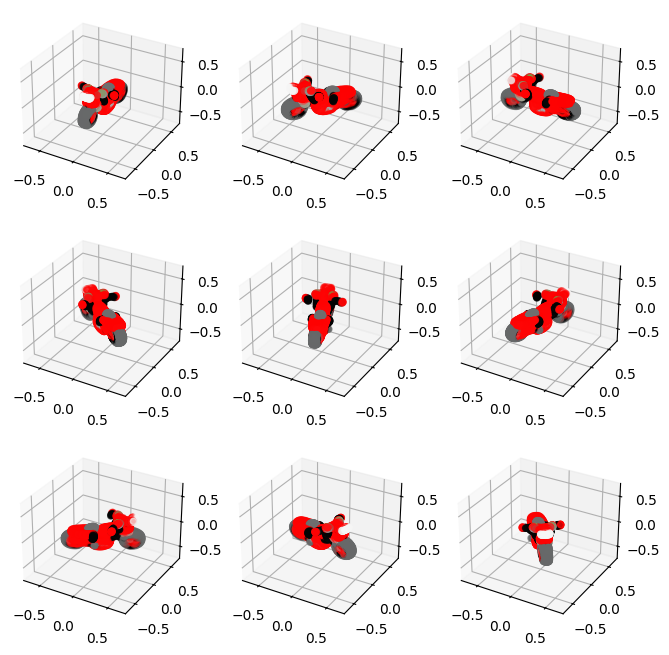

In [3]:
import torch
from tqdm.auto import tqdm

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.plotting import plot_point_cloud

print("CUDA 사용 가능:", torch.cuda.is_available())
print("GPU 정보:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "사용 불가")

# 장치 설정 (GPU 사용 가능시 GPU, 아니면 CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 기본 모델 생성
print('creating base model...')
base_name = 'base40M-textvec'
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.eval()
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

# 업샘플링 모델 생성
print('creating upsample model...')
upsampler_model = model_from_config(MODEL_CONFIGS['upsample'], device)
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS['upsample'])

# 모델 체크포인트 다운로드
print('downloading base checkpoint...')
base_model.load_state_dict(load_checkpoint(base_name, device))

print('downloading upsampler checkpoint...')
upsampler_model.load_state_dict(load_checkpoint('upsample', device))

# 샘플러 생성
sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 4096 - 1024],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 0.0],
    model_kwargs_key_filter=('texts', ''), # Do not condition the upsampler at all
)

# 텍스트 프롬프트 정의
prompt = 'a red motorcycle'

# 샘플 생성
samples = None
for x in tqdm(sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(texts=[prompt]))):
    samples = x

# 포인트 클라우드 시각화
pc = sampler.output_to_point_clouds(samples)[0]
fig = plot_point_cloud(pc, grid_size=3, fixed_bounds=((-0.75, -0.75, -0.75),(0.75, 0.75, 0.75)))

### Point-E를 활용한 Image To 3D 생성 예제

OpenAI의 Point-E 모델을 사용하여 2D 이미지에서 3D 포인트 클라우드를 생성합니다. 

기본 모델과 업샘플링 모델을 연계하여 "cube_stack.jpg" 이미지로부터 고해상도 컬러 3D 포인트 클라우드를 생성하고 시각화합니다.

* base40M 기본 모델과 upsample 업샘플링 모델을 MODEL_CONFIGS에서 로드하고 디퓨전 설정 구성
* load_checkpoint 함수로 사전 훈련된 모델 가중치를 다운로드하고 각 모델에 state_dict 로드
* PointCloudSampler를 생성하여 1024개 포인트에서 4096개로 업샘플링하고 RGB 색상 채널과 guidance_scale=[3.0, 3.0] 설정
* PIL.Image.open으로 "cube_stack.jpg" 이미지를 로드하고 sample_batch_progressive에 images=[img] 파라미터로 전달
* 생성된 샘플을 output_to_point_clouds로 포인트 클라우드 변환하고 plot_point_cloud로 3D 시각화

creating base model...
creating upsample model...
downloading base checkpoint...
downloading upsampler checkpoint...


0it [00:00, ?it/s]

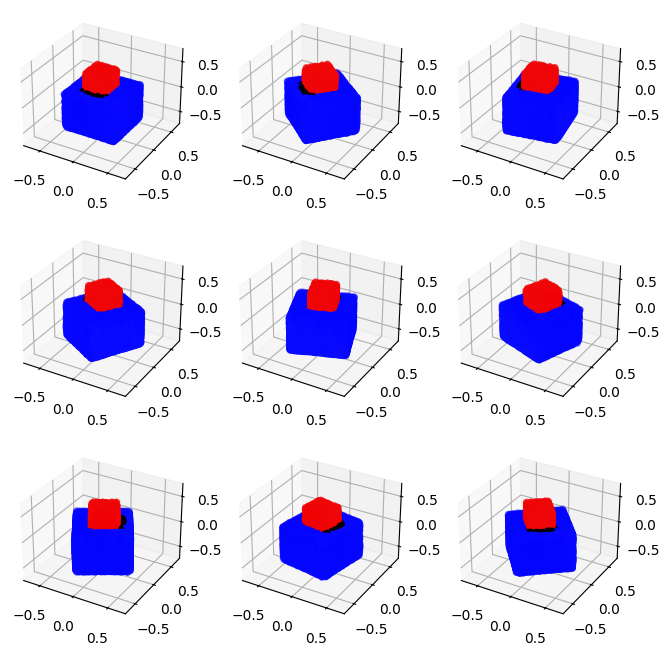

In [5]:
from PIL import Image
import torch
from tqdm.auto import tqdm

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.plotting import plot_point_cloud

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('creating base model...')
base_name = 'base40M' # 더 나은 결과를 원한다면 base300M 또는 base1B를 사용
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.eval()
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

print('creating upsample model...')
upsampler_model = model_from_config(MODEL_CONFIGS['upsample'], device)
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS['upsample'])

print('downloading base checkpoint...')
base_model.load_state_dict(load_checkpoint(base_name, device))

print('downloading upsampler checkpoint...')
upsampler_model.load_state_dict(load_checkpoint('upsample', device))

sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 4096 - 1024],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 3.0],
)

# 사용할 이미지를 불러오기
img = Image.open('./image/cube_stack.jpg')

# 모델로부터 샘플 생성
samples = None
for x in tqdm(sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(images=[img]))):
    samples = x
pc = sampler.output_to_point_clouds(samples)[0]
fig = plot_point_cloud(pc, grid_size=3, fixed_bounds=((-0.75, -0.75, -0.75),(0.75, 0.75, 0.75)))